# Ham, spam or phishing

Charts for the three-way experiment in [PHISHING.md](../PHISHING.md) and the
[out-of-distribution test](../OUT_OF_DISTRIBUTION.md): where TypeSafe and a TF-IDF classifier put
each email, how the answers changed when the phishing description spelled out urgency and authority,
how much TypeSafe's confidence tells you, and what happens on email unlike anything the classifier
learned from.

Everything is read from `results/`, which holds each message's answers and the classifier's saved
predictions, so this notebook needs neither the email itself nor an API key.

The phishing messages come from [Jose Nazario's phishing corpus](https://monkey.org/~jose/phishing/)
(CC BY 4.0). The modern test also uses Bruce Guenter's [spam archive](http://untroubled.org/spam/)
and public Python mailing-list archives. Thanks to all of them.

In [1]:
import json
import math
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize, to_rgb
from matplotlib.patches import Rectangle

ROOT = Path.cwd() if (Path.cwd() / "results").is_dir() else Path.cwd().parent
RESULTS = ROOT / "results"

CLASSES = ["ham", "spam", "phish"]
CLASS_NAMES = {"ham": "legitimate", "spam": "spam", "phish": "phishing"}
OPTION_TO_CLASS = {"legitimate": "ham", "spam": "spam", "phishing": "phish"}
QUESTIONS = {
    "category": "TypeSafe, descriptions",
    "category_urgency_authority": "TypeSafe, urgency and authority",
    "category_names_only": "TypeSafe, names only",
}


def rows_of(name):
    return [json.loads(line) for line in (RESULTS / name).open()]


def load(set_name, results_file):
    """TypeSafe answers and the saved TF-IDF probabilities for one test set, in the same order."""
    answers = {r["file"]: r for r in rows_of(results_file) if "choices" in r}
    tfidf = [r for r in rows_of("phish_tfidf_predictions.jsonl") if r["set"] == set_name]
    rows = [answers[r["file"]] for r in tfidf]
    probs = np.array([[r["probabilities"][c] for c in CLASSES] for r in tfidf])
    print(f"{set_name}: {len(rows)} messages {dict(Counter(r['label'] for r in rows))}")
    return rows, probs


def called(row, question):
    return OPTION_TO_CLASS[row["choices"][question]["choice"]]


def confusion(actual, guess):
    return np.array([[sum(a == ac and g == gc for a, g in zip(actual, guess)) for gc in CLASSES] for ac in CLASSES])


main_rows, main_tfidf = load("main", "phish_main_all.jsonl")
fresh_rows, fresh_tfidf = load("fresh", "phish_fresh.jsonl")
recent_rows = [r for r in rows_of("phish_recent.jsonl") if "choices" in r]
print(f"recent phishing: {len(recent_rows)} messages")

main: 5733 messages {'phish': 1911, 'ham': 1911, 'spam': 1911}
fresh: 3300 messages {'phish': 1100, 'ham': 1100, 'spam': 1100}
recent phishing: 853 messages


## How the charts are drawn

In every matrix, rows are the true category and columns are what the model called it. Only mistakes
are colored, on one blue scale shared across a figure, so a darker cell always means more emails.
Correct answers are gray.

In [2]:
RAMP = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7", "#3987e5",
        "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]
NEUTRAL, INK, INK_2, SURFACE = "#f0efec", "#0b0b0b", "#52514e", "#fcfcfb"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]  # blue, orange, aqua: fixed order, never reassigned
MISTAKES = LinearSegmentedColormap.from_list("mistakes", RAMP)


def scale_for(matrices):
    top = max(int(m[r, c]) for m in matrices for r in range(3) for c in range(3) if r != c)
    step = 10 ** math.floor(math.log10(max(top, 1)))
    return Normalize(0, math.ceil(max(top, 1) / step) * step)


def ink_on(fill):
    channels = [c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4 for c in to_rgb(fill)]
    luminance = 0.2126 * channels[0] + 0.7152 * channels[1] + 0.0722 * channels[2]
    return "white" if 1.05 / (luminance + 0.05) > (luminance + 0.05) / 0.05 else INK


def draw_matrix(ax, m, title, norm, totals):
    gap = 0.03
    ax.set_facecolor(SURFACE)
    for r in range(3):
        for c in range(3):
            correct = r == c
            fill = NEUTRAL if correct else MISTAKES(norm(m[r, c]))
            ax.add_patch(Rectangle((c + gap, r + gap), 1 - 2 * gap, 1 - 2 * gap, facecolor=fill, edgecolor="none"))
            color = INK if correct else ink_on(fill)
            ax.text(c + 0.5, r + 0.42, f"{m[r, c]:,}", fontsize=13, fontweight="bold", color=color, ha="center")
            ax.text(c + 0.5, r + 0.72, f"{m[r, c] / totals[r]:.1%}", fontsize=8.5, color=color, ha="center")
    ax.set_xlim(0, 3)
    ax.set_ylim(3, 0)
    ax.set_xticks([0.5, 1.5, 2.5], [f"called\n{CLASS_NAMES[c]}" for c in CLASSES])
    ax.set_yticks([0.5, 1.5, 2.5], [f"{CLASS_NAMES[c]}\n{totals[i]:,}" for i, c in enumerate(CLASSES)])
    ax.xaxis.tick_top()
    ax.tick_params(length=0, labelsize=9, labelcolor=INK_2)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title, loc="left", fontsize=10.5, color=INK, pad=30)


def scale_key(ax, norm):
    ax.axis("off")
    bar = ax.inset_axes([0.05, 0.52, 0.8, 0.07])
    colorbar = plt.colorbar(ScalarMappable(norm, MISTAKES), cax=bar, orientation="horizontal")
    colorbar.outline.set_visible(False)
    colorbar.ax.tick_params(labelsize=9, labelcolor=INK_2, length=3, color=INK_2)
    ax.text(0.05, 0.70, "Mistakes (emails)", fontsize=10, color=INK, transform=ax.transAxes)
    ax.add_patch(Rectangle((0.05, 0.28), 0.07, 0.06, facecolor=NEUTRAL, edgecolor="none", transform=ax.transAxes))
    ax.text(0.15, 0.31, "Correct answers", fontsize=10, color=INK, va="center", transform=ax.transAxes)


def plot_set(title, rows, tfidf_probs, tfidf_title):
    actual = [r["label"] for r in rows]
    totals = [actual.count(c) for c in CLASSES]
    panels = [(label, confusion(actual, [called(r, q) for r in rows])) for q, label in QUESTIONS.items()]
    panels.append((tfidf_title, confusion(actual, [CLASSES[k] for k in tfidf_probs.argmax(axis=1)])))
    norm = scale_for([m for _, m in panels])

    fig, axes = plt.subplots(2, 3, figsize=(14, 8.4), facecolor=SURFACE, layout="constrained")
    for ax, (name, m) in zip([axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]], panels):
        draw_matrix(ax, m, f"{name}\n{np.trace(m) / m.sum():.1%} correct", norm, totals)
    scale_key(axes[0, 2], norm)
    axes[1, 2].axis("off")
    fig.suptitle(title, x=0.01, ha="left", fontsize=13, color=INK)
    plt.show()

## Main test

5,733 emails, equally split between the three categories. The phishing comes from the 2005–07
mailbox; ham and spam from email-dataset. The TF-IDF classifier was scored by cross-validation, so
no email was scored by a model that had seen it.

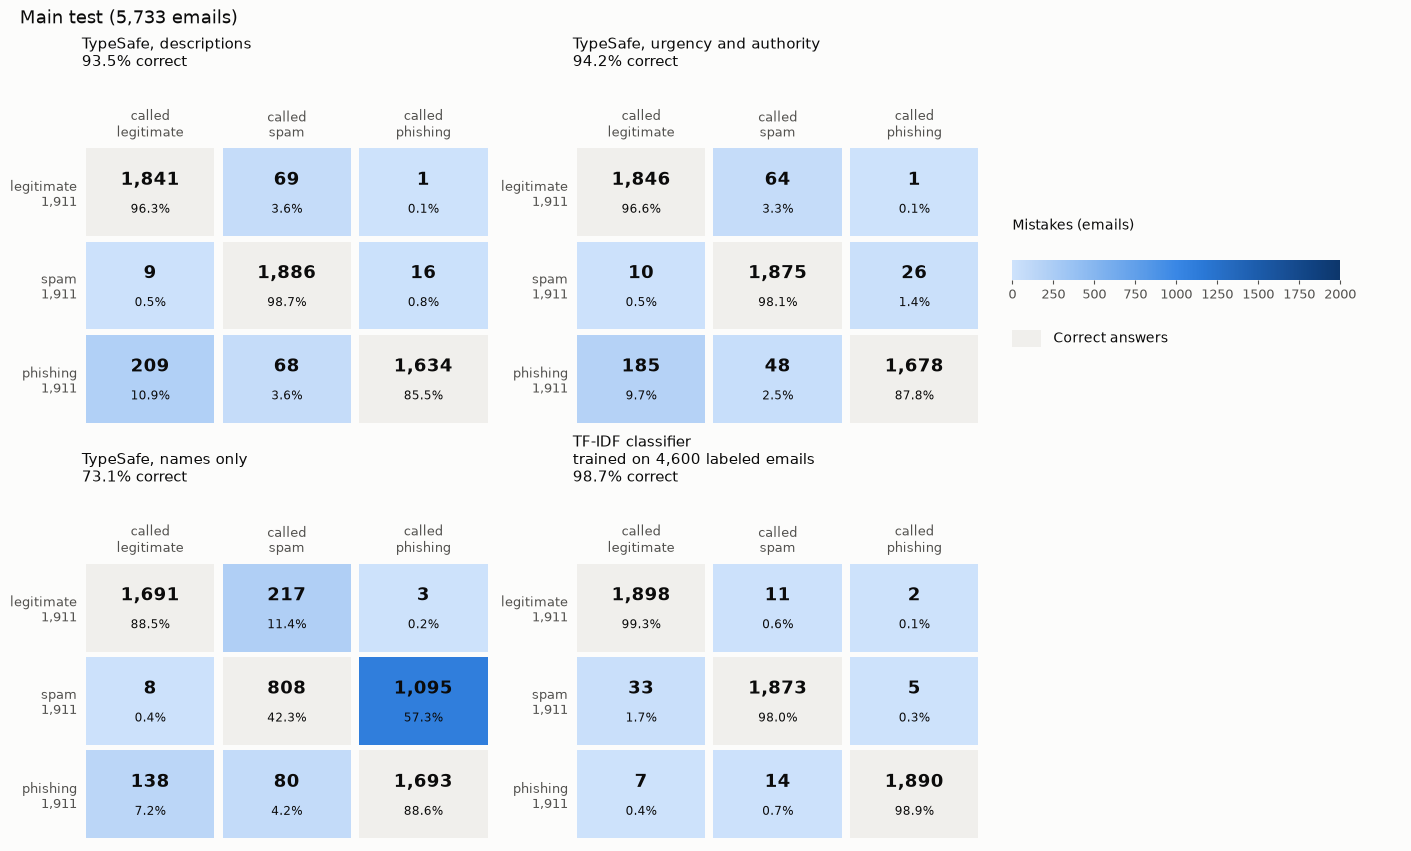

In [3]:
plot_set("Main test (5,733 emails)", main_rows, main_tfidf,
         "TF-IDF classifier\ntrained on 4,600 labeled emails")

## What changed when urgency and authority were added

The second description names two tactics phishing relies on: pretending to come from someone the
reader trusts, and pressing them to act at once. It was written after reading the main test's
mistakes, which is why the fresh test below matters.

In [4]:
def changes(rows):
    moves = Counter()
    for r in rows:
        before, after = called(r, "category"), called(r, "category_urgency_authority")
        if before != after:
            moves[(r["label"], before, after)] += 1
    return moves


for name, rows in (("Main test", main_rows), ("Fresh test", fresh_rows)):
    moves = changes(rows)
    better = sum(n for (actual, _, after), n in moves.items() if after == actual)
    worse = sum(n for (actual, before, _), n in moves.items() if before == actual)
    lines = [f"**{name}**: {sum(moves.values())} answers changed, {better} to the right category, "
             f"{worse} away from it.", "", "| True category | Was called | Now called | Emails |", "|---|---|---|---|"]
    for (actual, before, after), n in moves.most_common():
        lines.append(f"| {CLASS_NAMES[actual]} | {CLASS_NAMES[before]} | {CLASS_NAMES[after]} | {n} |")
    display(Markdown("\n".join(lines)))

**Main test**: 70 answers changed, 54 to the right category, 16 away from it.

| True category | Was called | Now called | Emails |
|---|---|---|---|
| phishing | legitimate | phishing | 25 |
| phishing | spam | phishing | 20 |
| spam | spam | phishing | 10 |
| legitimate | spam | legitimate | 9 |
| legitimate | legitimate | spam | 4 |
| phishing | phishing | legitimate | 1 |
| spam | spam | legitimate | 1 |

**Fresh test**: 17 answers changed, 12 to the right category, 5 away from it.

| True category | Was called | Now called | Emails |
|---|---|---|---|
| phishing | legitimate | phishing | 5 |
| phishing | spam | phishing | 4 |
| legitimate | spam | legitimate | 3 |
| legitimate | legitimate | spam | 3 |
| spam | spam | phishing | 2 |

## Fresh test

3,300 emails that played no part in writing any of the questions: phishing from a different mailbox,
and ham and spam not used in the main test. The TF-IDF classifier was trained on the whole main test
and scored here, so this is new email for it too.

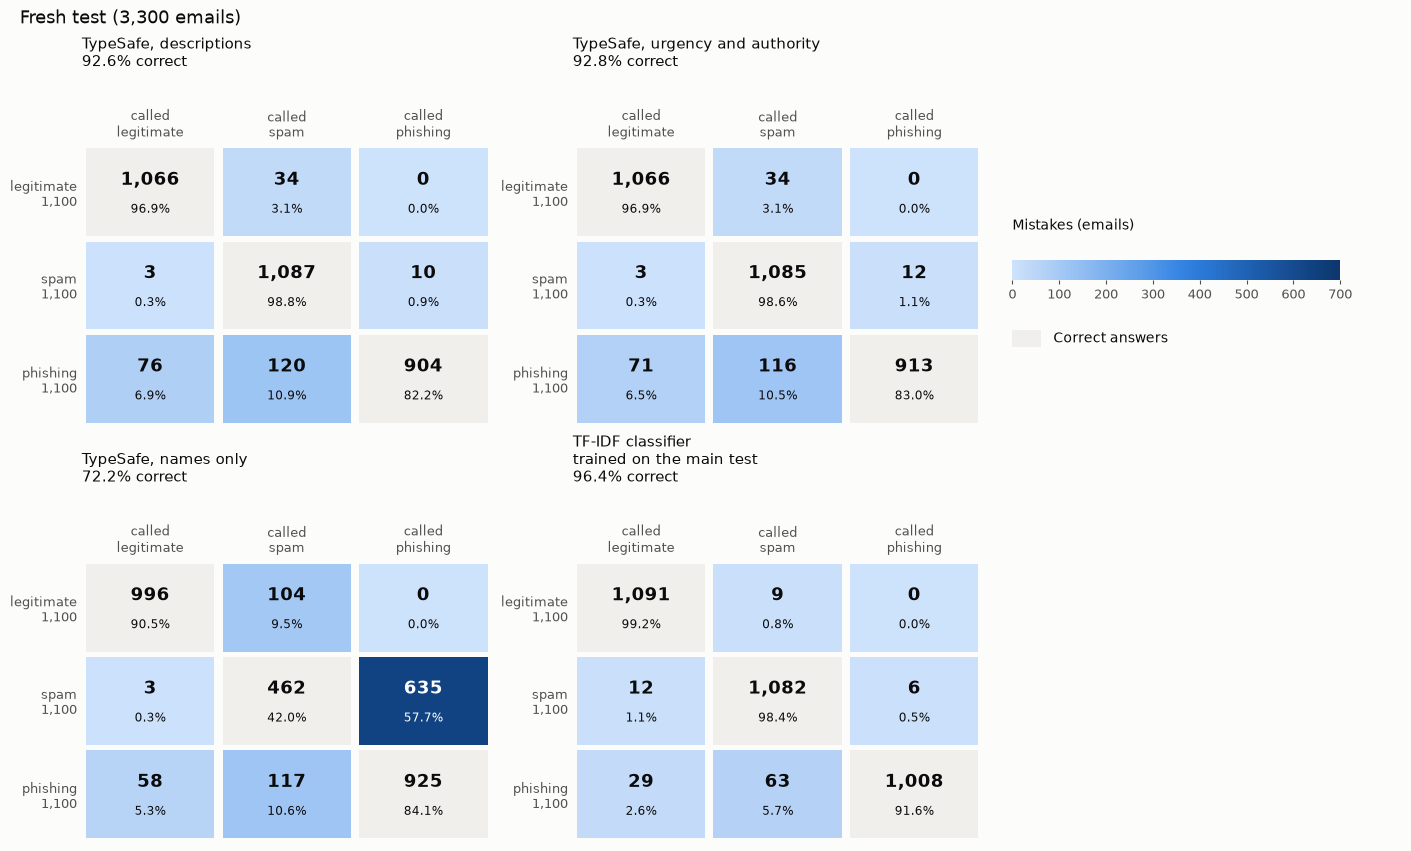

In [5]:
plot_set("Fresh test (3,300 emails)", fresh_rows, fresh_tfidf,
         "TF-IDF classifier\ntrained on the main test")

## Does confidence tell you when to trust the answer?

A Choice question returns a confidence score along with its answer. The classifier's equivalent is
how much probability it puts on its top category. Both are grouped into bands here, with the share
of emails in each band under the bars.

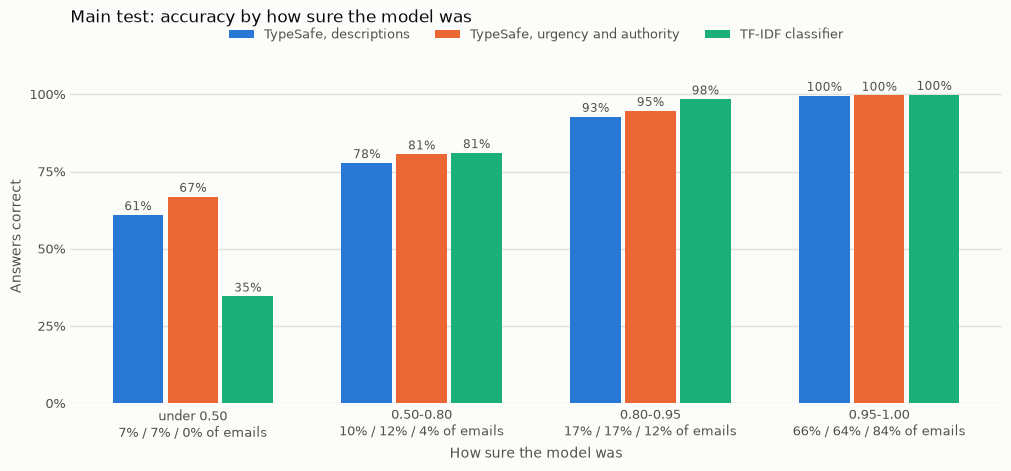

In [6]:
BANDS = [(0.0, 0.5), (0.5, 0.8), (0.8, 0.95), (0.95, 1.01)]
BAND_LABELS = ["under 0.50", "0.50-0.80", "0.80-0.95", "0.95-1.00"]

fig, ax = plt.subplots(figsize=(10, 4.6), facecolor=SURFACE, layout="constrained")
ax.set_facecolor(SURFACE)
actual = [r["label"] for r in main_rows]
series = [
    ("TypeSafe, descriptions", [called(r, "category") == a for r, a in zip(main_rows, actual)],
     [r["choices"]["category"]["confidence"] for r in main_rows]),
    ("TypeSafe, urgency and authority",
     [called(r, "category_urgency_authority") == a for r, a in zip(main_rows, actual)],
     [r["choices"]["category_urgency_authority"]["confidence"] for r in main_rows]),
    ("TF-IDF classifier", [CLASSES[k] == a for k, a in zip(main_tfidf.argmax(axis=1), actual)],
     list(main_tfidf.max(axis=1))),
]
width, shares = 0.24, []
for offset, (name, correct, confidence) in zip((-width, 0, width), series):
    accuracy, share = [], []
    for lo, hi in BANDS:
        idx = [i for i, c in enumerate(confidence) if lo <= c < hi]
        accuracy.append(np.mean([correct[i] for i in idx]) if idx else np.nan)
        share.append(len(idx) / len(main_rows))
    shares.append(share)
    x = np.arange(len(BANDS)) + offset
    ax.bar(x, accuracy, width=width * 0.92, color=SERIES[len(shares) - 1], label=name, zorder=3)
    for xi, value in zip(x, accuracy):
        if not np.isnan(value):
            ax.text(xi, value + 0.015, f"{value:.0%}", ha="center", fontsize=8.5, color=INK_2)

ax.set_xticks(np.arange(len(BANDS)),
              [f"{label}\n{shares[0][i]:.0%} / {shares[1][i]:.0%} / {shares[2][i]:.0%} of emails"
               for i, label in enumerate(BAND_LABELS)])
ax.set_ylim(0, 1.08)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0], ["0%", "25%", "50%", "75%", "100%"])
ax.set_ylabel("Answers correct", fontsize=10, color=INK_2)
ax.set_xlabel("How sure the model was", fontsize=10, color=INK_2)
ax.tick_params(length=0, labelsize=9, labelcolor=INK_2)
ax.grid(axis="y", color="#e1e0d9", linewidth=1, zorder=0)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(frameon=False, fontsize=9, labelcolor=INK_2, loc="upper center", bbox_to_anchor=(0.5, 1.16), ncol=3)
ax.set_title("Main test: accuracy by how sure the model was", loc="left", fontsize=12, color=INK, pad=34)
plt.show()

## Email the classifier was never trained for

The same comparison on three sets that don't match the classifier's training mail: Ling-Spam from
2000, phishing from 2024–25, and 2026 mailing-list posts and spam-trap mail. TypeSafe's questions
were unchanged. Full description in [OUT_OF_DISTRIBUTION.md](../OUT_OF_DISTRIBUTION.md).

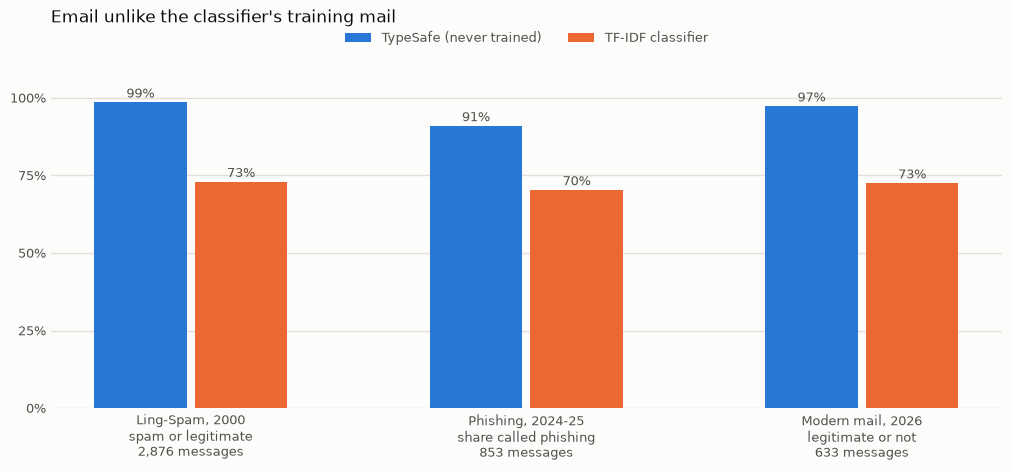

In [7]:
ood = rows_of("ood_tfidf_predictions.jsonl")
lingspam_answers = {r["file"]: r for r in rows_of("results_lingspam_criteria_all.jsonl") if "nouls" in r}
modern_answers = {r["file"]: r for r in rows_of("ood_modern.jsonl") if "choices" in r}

lingspam = [r for r in ood if r["set"] == "lingspam"]
ts_lingspam = np.mean([(lingspam_answers[r["file"]]["nouls"]["spam_plain"] >= 0.5) == (r["label"] == "spam")
                       for r in lingspam])
lr_lingspam = np.mean([(r["spam_probability"] >= 0.5) == (r["label"] == "spam") for r in lingspam])

recent = [r for r in ood if r["set"] == "recent_phishing"]
ts_recent = np.mean([called(recent_rows[i], "category_urgency_authority") == "phish" for i in range(len(recent_rows))])
lr_recent = np.mean([r["tfidf_call"] == "phish" for r in recent])

modern = [r for r in ood if r["set"] == "modern"]
ts_modern = np.mean([(called(modern_answers[r["file"]], "category_urgency_authority") != "ham")
                     == (r["label"] == "not_ham") for r in modern])
lr_modern = np.mean([(r["tfidf_call"] != "ham") == (r["label"] == "not_ham") for r in modern])

tests = [f"Ling-Spam, 2000\nspam or legitimate\n{len(lingspam):,} messages",
         f"Phishing, 2024-25\nshare called phishing\n{len(recent)} messages",
         f"Modern mail, 2026\nlegitimate or not\n{len(modern)} messages"]
typesafe, tfidf = [ts_lingspam, ts_recent, ts_modern], [lr_lingspam, lr_recent, lr_modern]

fig, ax = plt.subplots(figsize=(10, 4.6), facecolor=SURFACE, layout="constrained")
ax.set_facecolor(SURFACE)
x, width = np.arange(len(tests)), 0.3
for offset, values, name, color in ((-width / 2, typesafe, "TypeSafe (never trained)", SERIES[0]),
                                    (width / 2, tfidf, "TF-IDF classifier", SERIES[1])):
    ax.bar(x + offset, values, width=width * 0.92, color=color, label=name, zorder=3)
    for xi, value in zip(x + offset, values):
        ax.text(xi, value + 0.015, f"{value:.0%}", ha="center", fontsize=9.5, color=INK_2)
ax.set_xticks(x, tests)
ax.set_ylim(0, 1.1)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0], ["0%", "25%", "50%", "75%", "100%"])
ax.tick_params(length=0, labelsize=9, labelcolor=INK_2)
ax.grid(axis="y", color="#e1e0d9", linewidth=1, zorder=0)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(frameon=False, fontsize=9.5, labelcolor=INK_2, loc="upper center", bbox_to_anchor=(0.5, 1.14), ncol=2)
ax.set_title("Email unlike the classifier's training mail", loc="left", fontsize=12, color=INK, pad=32)
plt.show()